In [7]:
print("hi")

hi


In [8]:
import prompt_inspector
prompt_inspector.inspect()

AttributeError: module 'prompt_inspector' has no attribute 'inspect'

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

In [ ]:
from typing import TypedDict
from dotenv import load_dotenv

In [ ]:
import os
load_dotenv(override=True)

True

In [ ]:
def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        max_tokens= 1000
    )

In [ ]:
llm= get_groq_llm()

In [ ]:
class LLMState(TypedDict):
    question: str
    answer: str

In [ ]:
def chat_llm(state: LLMState):

    question= state['question']

    ##prompt:
    prompt= f'Answer the following Question {question}'

    answer= llm.invoke(prompt).content
    
    state['answer']= answer

    return state


    


In [ ]:
graph= StateGraph(LLMState)

## add nodes

graph.add_node('chat_llm',chat_llm)

In [ ]:
## add edges

graph.add_edge(START,'chat_llm')
graph.add_edge('chat_llm', END)

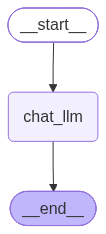

In [ ]:
workflow= graph.compile()

workflow

In [ ]:
intial_state= {'question':'How far is the moon from earth'}

final_state= workflow.invoke(intial_state)

print(final_state)

{'question': 'How far is the moon from earth', 'answer': 'The Moon orbits Earth at an average distance of about **384,400\u202fkilometers** (≈\u202f238,855\u202fmiles).  \n\n- **Perigee** (closest point): ~363,300\u202fkm (≈\u202f225,700\u202fmi)  \n- **Apogee** (farthest point): ~405,500\u202fkm (≈\u202f251,900\u202fmi)\n\nThese values vary slightly because the Moon’s orbit is elliptical and is also affected by gravitational interactions with the Sun and other bodies.'}


In [ ]:
print(final_state['answer'])

The Moon orbits Earth at an average distance of about **384,400 kilometers** (≈ 238,855 miles).  

- **Perigee** (closest point): ~363,300 km (≈ 225,700 mi)  
- **Apogee** (farthest point): ~405,500 km (≈ 251,900 mi)

These values vary slightly because the Moon’s orbit is elliptical and is also affected by gravitational interactions with the Sun and other bodies.


In [ ]:
intial_state= {'question':'okay great but how far from Sun?'}

final_state= workflow.invoke(intial_state)

In [ ]:
print(final_state)

{'question': 'okay great but how far from Sun?', 'answer': 'Sure!\u202fThe distance of an object from the Sun depends on what that object is, but the most common reference point is **Earth**, whose average distance defines the astronomical unit (AU).\n\n| Body                | Average distance from the Sun | Range (closest‑farther) | In astronomical units (AU) |\n|---------------------|------------------------------|--------------------------|----------------------------|\n| **Earth**           | **149.6\u202fmillion\u202fkm** (≈93\u202fmillion\u202fmi) | 147.1\u202fM\u202fkm (perihelion) – 152.1\u202fM\u202fkm (aphelion) | **1\u202fAU** |\n| Mercury             | 57.9\u202fM\u202fkm (0.387\u202fAU)          | 46.0\u202fM\u202fkm – 69.8\u202fM\u202fkm    | 0.39\u202fAU |\n| Venus               | 108.2\u202fM\u202fkm (0.723\u202fAU)         | 107.5\u202fM\u202fkm – 108.9\u202fM\u202fkm  | 0.72\u202fAU |\n| Mars                | 227.9\u202fM\u202fkm (1.524\u202fAU)         | 206.6\u202fM

In [ ]:
print(final_state['answer'])


Sure! The distance of an object from the Sun depends on what that object is, but the most common reference point is **Earth**, whose average distance defines the astronomical unit (AU).

| Body                | Average distance from the Sun | Range (closest‑farther) | In astronomical units (AU) |
|---------------------|------------------------------|--------------------------|----------------------------|
| **Earth**           | **149.6 million km** (≈93 million mi) | 147.1 M km (perihelion) – 152.1 M km (aphelion) | **1 AU** |
| Mercury             | 57.9 M km (0.387 AU)          | 46.0 M km – 69.8 M km    | 0.39 AU |
| Venus               | 108.2 M km (0.723 AU)         | 107.5 M km – 108.9 M km  | 0.72 AU |
| Mars                | 227.9 M km (1.524 AU)         | 206.6 M km – 249.2 M km  | 1.52 AU |
| Jupiter             | 778.5 M km (5.204 AU)         | 740.5 M km – 816.6 M km  | 5.20 AU |
| Saturn              | 1 433 M km (9.582 AU)         | 1 353 M km – 1 511 M km  | 9.58 AU |
|

## Call to llm:
## Stateless Calls: It does not have any previous message history



##

User_query_no1: hsxbshbxh
llm: hsxbhjsxhbv

user_q2: follow up question
llm: proper answe

## sending all prev, info to llm